In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [3]:
def model(x0, theta, key,days, delta_t):
    gamma,xi,damping,log_mean,log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=jnp.arange(0, days, delta_t),
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

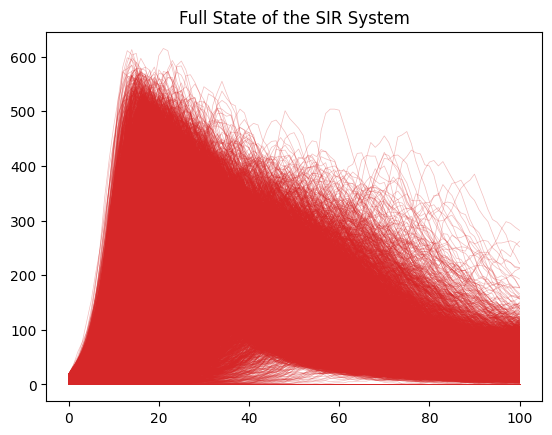

In [4]:
theta = (0.1, 1 / 90,1/35,jnp.log(0.35),0.2)
delta_t = 1.0
days = 100
rng_key = jax.random.key(10)

num_models = 10000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key,minval = 0,maxval = 20,shape = (num_models,))

x0 = jnp.full(
    shape=(num_models, 3), fill_value=jnp.array([1000, 0, 0])
)

x0 = x0.at[:,0].set(x0[:,0] - I_x0)
x0 = x0.at[:,1].set(x0[:,1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key,shape = (num_models,),minval = 0.1,maxval = 0.5)

beta_x0 = beta_x0[...,jnp.newaxis]

x0 = jnp.concatenate((x0,jnp.log(beta_x0)),axis = -1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None, None))(
    x0, theta, keys, days, delta_t
)

plt.title("Full State of the SIR System")
for model_index in range(num_models):
    plt.plot(
        jnp.arange(0, days + delta_t, delta_t),
        full_state[model_index, :, 1],
        lw=0.5,
        alpha=0.3,
        color="tab:red",
    )
plt.show()

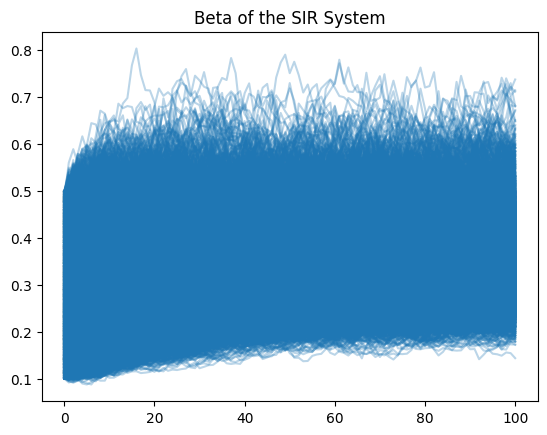

In [5]:
plt.title('Beta of the SIR System')
plt.plot(jnp.arange(0,days+delta_t,delta_t),jnp.exp(full_state[:,:,3]).T,color = 'tab:blue',alpha = 0.3)
plt.show()

In [6]:
def particle_filter(observations, delta_t, initial_particles, key, likelihood):

    num_particles = initial_particles.shape[0]

    def filter_step(state, i):
        prev_particles, prev_key = state

        forecast_key, next_key = jax.random.split(prev_key)
        forecast_keys = jax.random.split(forecast_key, num_particles)
        forecast_particles = jax.vmap(model, in_axes=(0, None, 0, None, None))(
            prev_particles, theta, forecast_keys, 1, delta_t
        )[:, -1, :]

        weights = likelihood(forecast_particles, observations[i])
        resampling_key, next_key = jax.random.split(next_key)
        indices = jax.random.choice(
            resampling_key, jnp.arange(0, num_particles), p=weights / jnp.sum(weights), shape = (num_particles,)
        )
        
        resampled_particles = forecast_particles[indices,:]

        return (resampled_particles, next_key), resampled_particles

    return jax.lax.scan(
        filter_step, (initial_particles, key), xs=jnp.arange(0, len(observations))
    )


In [7]:
def likelihood(particles,observation): 
    return jax.scipy.stats.poisson.pmf(observation, mu = particles[:,1])

In [8]:
pf_init_key,rng_key = jax.random.split(rng_key)

num_particles = 25

particles = jnp.full(
    shape=(num_models, num_particles, 3), fill_value=jnp.array([1000, 0, 0])
)

particles_I = jax.random.randint(pf_init_key, shape = (num_models, num_particles),minval = 0,maxval = 20)

particles = particles.at[:,:,1].set(particles[:, :,1] + particles_I)
particles = particles.at[:,:,0].set(particles[:, :,0] - particles_I)

beta_init_key,rng_key = jax.random.split(rng_key)

particle_betas = jax.random.uniform(beta_init_key,shape = (num_models,num_particles,1),minval = 0.1,maxval = 0.5)
particles = jnp.concatenate((particles,jnp.log(particle_betas)),axis = -1)

cutoff_day = 7

observations = full_state[:,:cutoff_day,1]

pf_key,rng_key = jax.random.split(rng_key)
pf_keys = jax.random.split(pf_key,num_models)
_,particles = jax.vmap(particle_filter, in_axes=(0, None, 0, 0,None))(observations, delta_t, particles, pf_keys,likelihood)

In [9]:
def get_rank_histogram(truth, ensemble, key):
    obs = truth[:,-1,jnp.newaxis]
    ens = ensemble

    def rank_eval(ens, obs,key):
        is_smaller = ens < obs
        is_tied = ens == obs
        num_smaller = jnp.sum(is_smaller,axis = 0)
        num_tied = jnp.sum(is_tied,axis = 0)

        offset = jax.random.randint(key, num_smaller.shape, 0, num_tied + 1)

        return num_smaller + offset

    offset_keys = jax.random.split(key,truth.shape[0])
    ranks = jax.vmap(rank_eval, in_axes=(0, 0,0))(ens, obs,offset_keys)

    return ranks

def chi_square_test(observed, expected): 
    return jnp.sum(jnp.square(observed - expected) / expected)

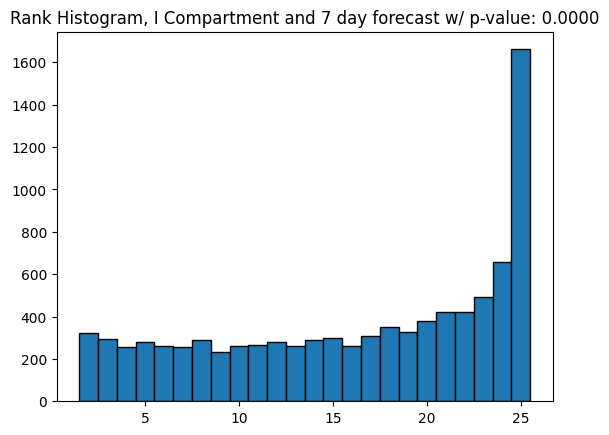

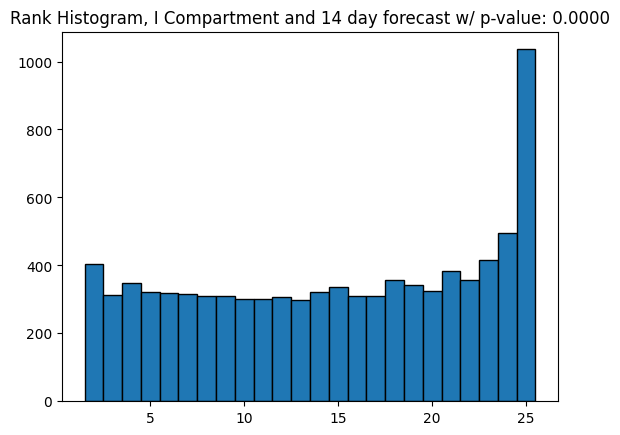

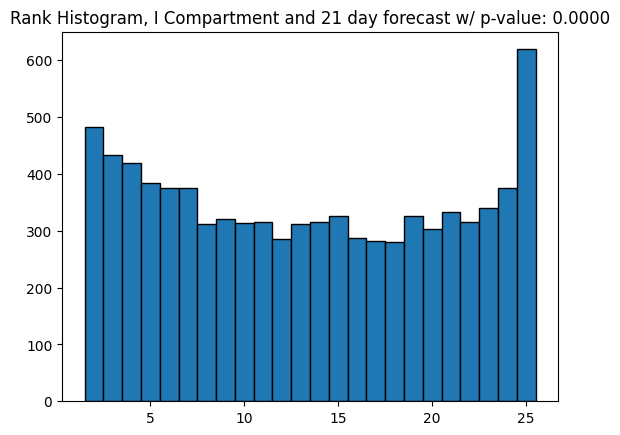

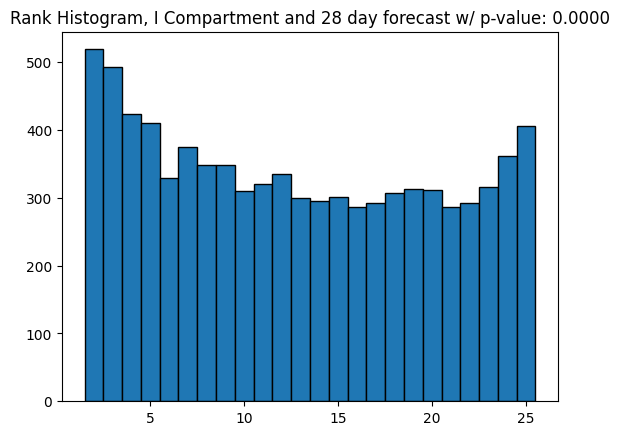

In [10]:
### Forecasting

forecast_horizons = [1 * 7, 2 * 7, 3 * 7, 4 * 7]  # 4 weeks

theta_forecast = (0.1, 1 / 90, 1 / 35, jnp.log(0.35), 0.2)


def forecast_run(IC, theta, num_particles, key, horizon):

    forecast_key, key = jax.random.split(key)
    forecast_keys = jax.random.split(forecast_key, num_particles)
    forecast = jax.vmap(model, in_axes=(0, None, 0, None, None))(
        IC, theta, forecast_keys, horizon, delta_t
    )

    return forecast


for horizon in forecast_horizons:
    forecast_key, rng_key = jax.random.split(rng_key)
    forecast_keys = jax.random.split(forecast_key, num_models)
    forecasts = jax.vmap(forecast_run, in_axes=(0, None, None, 0, None))(
        particles[:, -1, :, :], theta_forecast, num_particles, forecast_keys, horizon
    )

    rank_key,rng_key = jax.random.split(rng_key)

    ranks = get_rank_histogram(
        full_state[
            :,
            int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
            + int(horizon / delta_t)
            + 1,
            1,
        ],
        forecasts[:, :, -1, 1],
        rank_key
    )



    num_bins = num_particles + 1
    rank_counts = jnp.bincount(ranks.reshape(-1), length=num_bins)

    total_observations = ranks.shape[0]
    expected_val = total_observations / num_bins
    expected_counts = jnp.full(num_bins, expected_val)

    stat = chi_square_test(rank_counts, expected_counts)
    df = num_bins - 1

    p_value = jax.scipy.stats.chi2.sf(stat, df)


    plt.title(
    f"Rank Histogram, I Compartment and {horizon} day forecast w/ p-value: {p_value:.4f}"
)

    plt.hist(
        ranks.reshape(-1), bins=jnp.arange(num_particles) + 1 + 0.5, edgecolor="black"
    )
    plt.show()